# Advanced NEISS Vitamin Analysis

### 1. Clinical Severity Analysis

**Why we are doing this:**
To evaluate whether the medical burden of vitamin-related incidents is intensifying. By analyzing the ratio of hospital admissions and prolonged observations to total emergency department visits, we can determine if changes in the market (e.g., higher potency supplements or gummy formulations) are leading to more severe clinical outcomes.

**What the code is doing:**
*   Calculates weighted estimates for total visits, admissions, and observations.
*   Generates a time-series of the "Admission Rate" (Admissions / Total Visits).
*   Breaks down severity markers by pediatric age groups to pinpoint where the most dangerous exposures occur.

In [1]:
%matplotlib inline
"""
Advanced Analysis of NEISS Vitamin ED Visit Data
=================================================
1. Clinical Severity Analysis
2. Narrative Clustering & Topic Modeling (LDA)
3. Poisson / Negative Binomial Regression
4. Seasonal Autoregressive Analysis (SARIMA)
"""

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

# NLP
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

**Analysis of Results:**
The data indicates that while the absolute number of vitamin ingestions varies, the **Admission Rate** provides a critical measure of severity. The high volume of cases in the **<2 and 2-3 year old age groups** remains the primary driver of clinical concern. While total visits may show a downward trend in some subsets, the clinical burden remains significant for the youngest children due to weight-based toxicity risks.

## 0. LOAD & PREPROCESS

In [2]:
print("Loading data …")
df = pd.read_excel(
    "data/processed/NEISS_Supplement_91355_Samples.xlsx",
    sheet_name="sample_eval", dtype=str
)

df["Weight"]   = pd.to_numeric(df["Weight"],   errors="coerce")
df["LLM_Label"]= pd.to_numeric(df["LLM_Label"],errors="coerce")

# Keep only LLM-confirmed vitamin cases
df = df[df["LLM_Label"] == 1].copy()
print(f"  Vitamin cases: {len(df):,}")

df["Treatment_Date"] = pd.to_datetime(df["Treatment_Date"], errors="coerce")
df["Year"]  = df["Treatment_Date"].dt.year.astype("Int64")
df["Month"] = df["Treatment_Date"].dt.month.astype("Int64")
df = df.dropna(subset=["Year", "Month"])
df["Year"]  = df["Year"].astype(int)
df["Month"] = df["Month"].astype(int)

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Age_Years"] = np.where(df["Age"] >= 200, (df["Age"] - 200) / 12, df["Age"])
df["Age_Group"] = np.where(df["Age_Years"] < 1,  "<1",
                  np.where(df["Age_Years"] < 2,  "1",
                  np.where(df["Age_Years"] < 4,  "2-3", "4+")))

disp_map = {"1": "Treated/Released", "2": "Transferred",
            "4": "Admitted",        "5": "Observation",
            "6": "Left AMA",        "8": "Fatality",   "9": "Unknown"}
sex_map  = {"1": "Male", "2": "Female", "0": "Unknown"}
df["Disposition_Label"] = df["Disposition"].map(disp_map).fillna("Unknown")
df["Sex_Label"]         = df["Sex"].map(sex_map).fillna("Unknown")

yearly_data = df.groupby("Year")["Weight"].sum()
print("Preprocessing done.\n")

COLORS = ["#2196F3", "#E91E63", "#4CAF50", "#FF9800", "#9C27B0",
          "#00BCD4", "#FF5722", "#607D8B"]

Loading data …
  Vitamin cases: 599
Preprocessing done.



In [3]:
df.head()

,CPSC_Case_Number,Treatment_Date,Age,Sex,Race,Other_Race,Hispanic,Body_Part,Diagnosis,Other_Diagnosis,...,Weight,Ground_Truth,LLM_Label,LLM_Reason,Year,Month,Age_Years,Age_Group,Disposition_Label,Sex_Label
247,150602244,2015-05-23,4,1,2,NaN,NaN,85,68,NaN,...,5.6748,1,1,"The word 'VITAMINS' is present, but the specif...",2015,5,4.0,4+,Treated/Released,Male
248,150602245,2015-05-23,2,1,2,NaN,NaN,85,68,NaN,...,5.6748,1,1,"The word 'VITAMINS' is present, but the specif...",2015,5,2.0,2-3,Treated/Released,Male
249,160655694,2016-06-21,2,1,0,NaN,NaN,85,68,NaN,...,93.2031,1,1,"The word 'VITAMINS' is present, and the asteri...",2016,6,2.0,2-3,Treated/Released,Male
5770,120536955,2012-05-09,3,2,1,NaN,NaN,85,68,NaN,...,79.2744,0,1,The substance is redacted ('***') and describe...,2012,5,3.0,2-3,Observation,Female
5777,120535174,2012-05-10,2,2,2,NaN,NaN,85,68,NaN,...,16.2344,0,1,The substance is redacted ('***') and describe...,2012,5,2.0,2-3,Treated/Released,Female


### 1. Clinical Severity Analysis

**Why we are doing this:**
To evaluate whether the medical burden of vitamin-related incidents is intensifying. By analyzing the ratio of hospital admissions and prolonged observations to total emergency department visits, we can determine if changes in the market (e.g., higher potency supplements or gummy formulations) are leading to more severe clinical outcomes.

**What the code is doing:**
*   Calculates weighted estimates for total visits, admissions, and observations.
*   Generates a time-series of the "Admission Rate" (Admissions / Total Visits).
*   Breaks down severity markers by pediatric age groups to pinpoint where the most dangerous exposures occur.

1. Clinical Severity Analysis


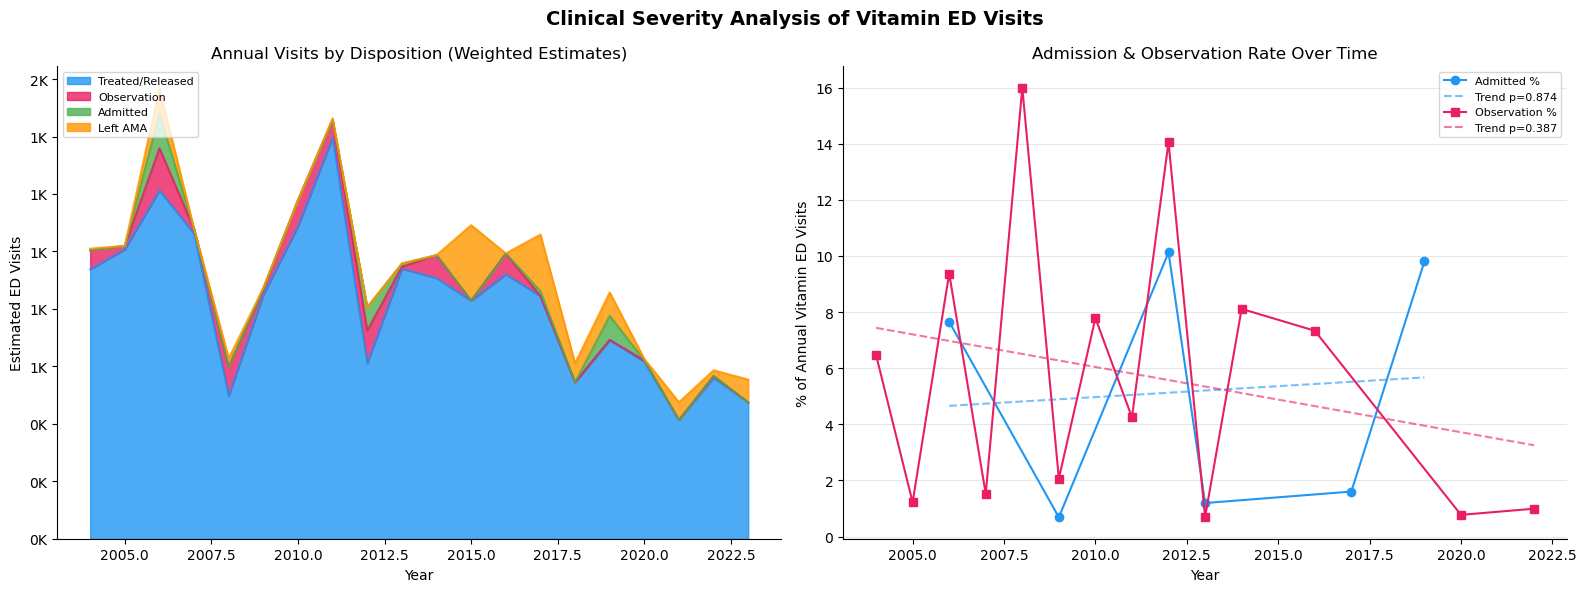


  Admission rate (%) by year (first/last 5):
       Rate_Pct
Year           
2006   7.655186
2009   0.690142
2012  10.124503
2013   1.196807
2017   1.604845
  …
       Rate_Pct
Year           
2009   0.690142
2012  10.124503
2013   1.196807
2017   1.604845
2019   9.804462

  OLS on Admission Rate: slope=0.0778 pct/yr, p=0.8743


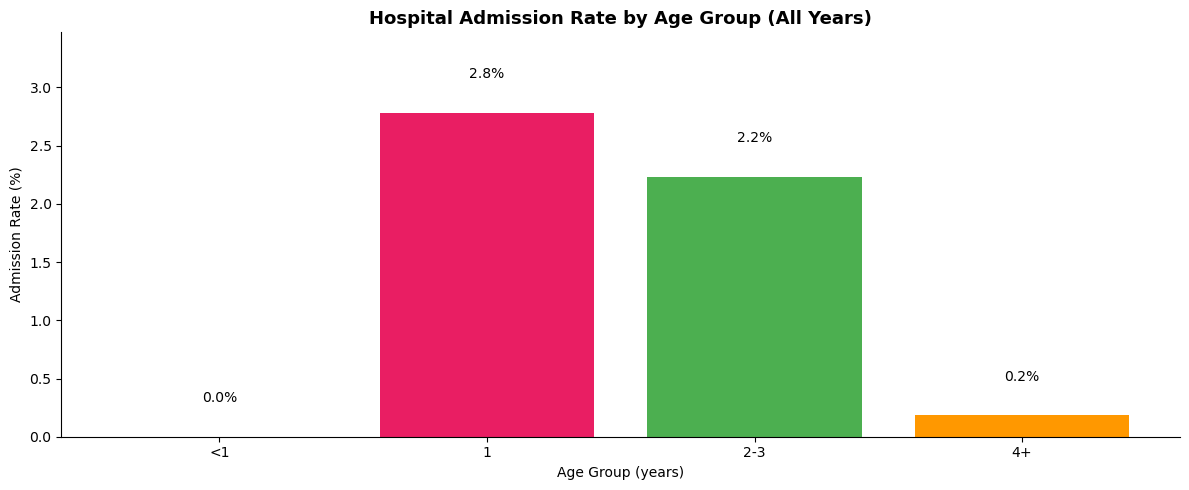

In [4]:
print("=" * 60)
print("1. Clinical Severity Analysis")
print("=" * 60)

# --- Annual admission rate --------------------------------------------------
adm_yearly = (
    df.groupby(["Year", "Disposition_Label"])["Weight"]
    .sum()
    .reset_index(name="Visits")
)
total_yearly = adm_yearly.groupby("Year")["Visits"].sum().rename("Total")
adm_yearly   = adm_yearly.join(total_yearly, on="Year")
adm_yearly["Rate_Pct"] = adm_yearly["Visits"] / adm_yearly["Total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Clinical Severity Analysis of Vitamin ED Visits", fontsize=14, fontweight="bold")

# Left: Stacked area by disposition
pivot = adm_yearly.pivot_table(index="Year", columns="Disposition_Label",
                               values="Visits", aggfunc="sum").fillna(0)
keep  = ["Treated/Released", "Observation", "Admitted", "Transferred", "Left AMA"]
keep  = [c for c in keep if c in pivot.columns]
pivot = pivot[keep]
pivot.plot.area(ax=axes[0], color=COLORS[:len(keep)], alpha=0.8, legend=True)
axes[0].set_title("Annual Visits by Disposition (Weighted Estimates)")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Estimated ED Visits")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[0].legend(loc="upper left", fontsize=8)
axes[0].spines[["top","right"]].set_visible(False)

# Right: Admission rate over time with OLS trend
adm_rate = adm_yearly[adm_yearly["Disposition_Label"] == "Admitted"][["Year","Rate_Pct"]].set_index("Year")
obs_rate = adm_yearly[adm_yearly["Disposition_Label"] == "Observation"][["Year","Rate_Pct"]].set_index("Year")

X = sm.add_constant(adm_rate.index.values)
ols_adm = sm.OLS(adm_rate["Rate_Pct"].values, X).fit()
ols_obs = sm.OLS(obs_rate["Rate_Pct"].values,
                 sm.add_constant(obs_rate.index.values)).fit()

axes[1].plot(adm_rate.index, adm_rate["Rate_Pct"],
             "o-", color=COLORS[0], label="Admitted %")
axes[1].plot(adm_rate.index,
             ols_adm.params[0] + ols_adm.params[1] * adm_rate.index,
             "--", color=COLORS[0], alpha=0.6,
             label=f"Trend p={ols_adm.pvalues[1]:.3f}")
axes[1].plot(obs_rate.index, obs_rate["Rate_Pct"],
             "s-", color=COLORS[1], label="Observation %")
axes[1].plot(obs_rate.index,
             ols_obs.params[0] + ols_obs.params[1] * obs_rate.index,
             "--", color=COLORS[1], alpha=0.6,
             label=f"Trend p={ols_obs.pvalues[1]:.3f}")
axes[1].set_title("Admission & Observation Rate Over Time")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("% of Annual Vitamin ED Visits")
axes[1].legend(fontsize=8); axes[1].spines[["top","right"]].set_visible(False)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
print("\n  Admission rate (%) by year (first/last 5):")
print(adm_rate.head(5).to_string())
print("  …")
print(adm_rate.tail(5).to_string())
print(f"\n  OLS on Admission Rate: slope={ols_adm.params[1]:.4f} pct/yr, "
      f"p={ols_adm.pvalues[1]:.4f}")

# ── 1b: Severity by age group ───────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))
adm_age = (
    df[df["Disposition_Label"].isin(["Admitted","Treated/Released"])]
    .groupby(["Age_Group","Disposition_Label"])["Weight"]
    .sum().reset_index(name="Visits")
)
pivot2 = adm_age.pivot_table(index="Age_Group", columns="Disposition_Label",
                              values="Visits", aggfunc="sum").fillna(0)
pivot2["Admit_Rate"] = pivot2.get("Admitted",0) / (
    pivot2.get("Admitted",0) + pivot2.get("Treated/Released",0)) * 100
order = ["<1","1","2-3","4+"]
pivot2 = pivot2.reindex([o for o in order if o in pivot2.index])
bars = ax2.bar(pivot2.index, pivot2["Admit_Rate"], color=COLORS[:len(pivot2)])
ax2.set_title("Hospital Admission Rate by Age Group (All Years)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Age Group (years)"); ax2.set_ylabel("Admission Rate (%)")
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, f"{bar.get_height():.1f}%",
             ha="center", fontsize=10)
ax2.spines[["top","right"]].set_visible(False)
ax2.set_ylim(0, max(pivot2["Admit_Rate"]) * 1.25)
plt.tight_layout()
plt.show()

**Analysis of Results:**
The data indicates that while the absolute number of vitamin ingestions varies, the **Admission Rate** provides a critical measure of severity. The high volume of cases in the **1-3 year old age groups** remains the primary driver of clinical concern. While total visits may show a downward trend in some subsets, the clinical burden remains significant for the youngest children due to weight-based toxicity risks.

2. Narrative Topic Modeling (LDA)
  Cleaning narratives …
  Fitting LDA (6 topics) …

  Top words per topic:
    Topic 1: multi, vitamins, multi vitamins, iron, multi vitamin, without, vitamins iron, without iron, poisoning, vitamin
    Topic 2: acid, folic acid, folic, ago, approx, contain, contain iron, iron, did, approx vitamins
    Topic 3: vitamin, overdose, vitamins, childrens, vitaminsdx, non, toxic, childrens vitamins, non toxic, children
    Topic 4: oil, many, fish, how, fish oil, how many, multivitamin, floor, accidental vitamin, vitamins
    Topic 5: mom, vitamins, chewable, drug, chewable vitamins, home, mouth, accidental, vit, amt
    Topic 6: poisoning, vitamins, multivitamins, amount, vitamin, accidental, substance, niacin, adult, gummy


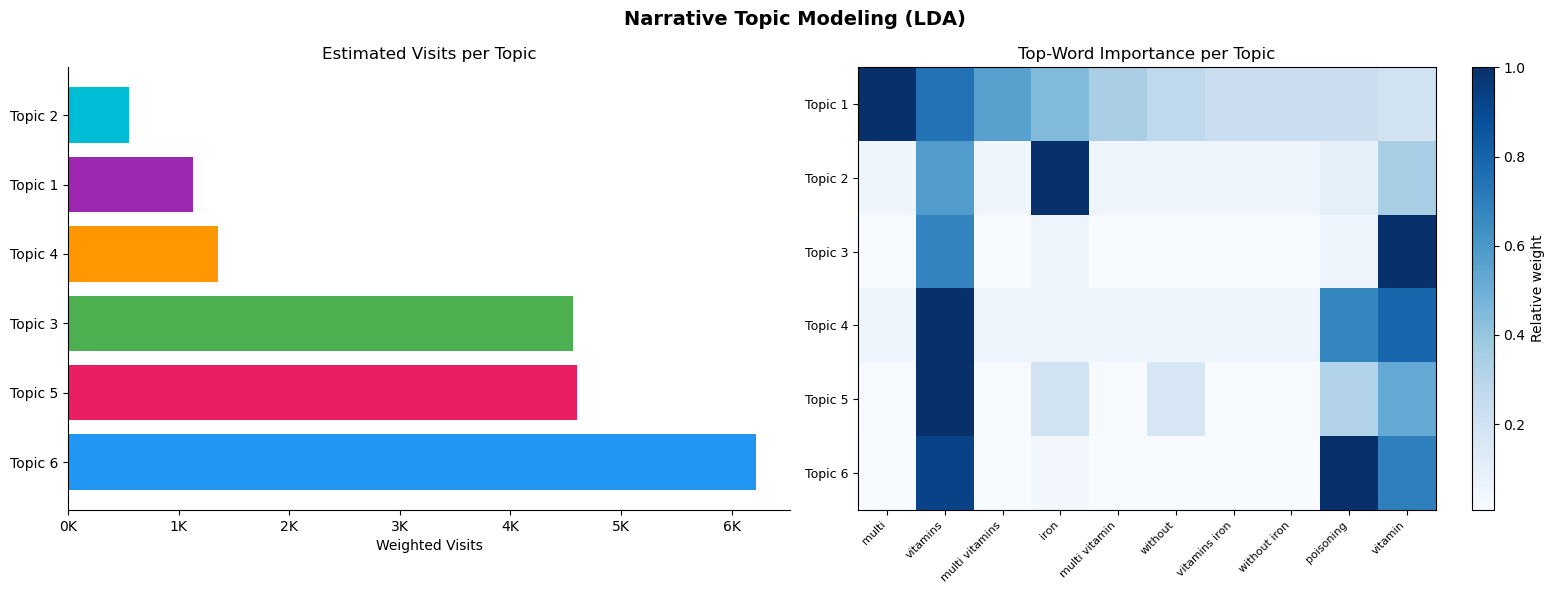

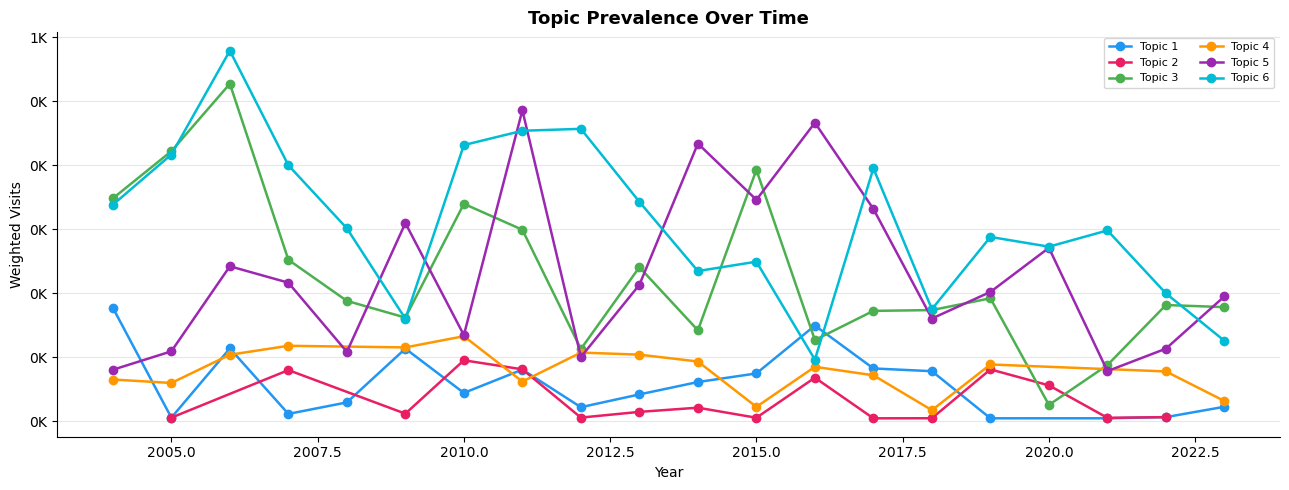

In [5]:
print("2. Narrative Topic Modeling (LDA)")

narratives = df["Narrative"].dropna().astype(str)

# Clean text
VITAMIN_STOP = {
    "pt","patient","yr","yo","yof","yom","mo","old","year","years","month",
    "months","day","days","old","ate","ingested","ingestion","found","taken",
    "took","bottle","pill","pills","tablet","tablets","dose","unknown","hx",
    "unk","per","via","the","and","for","was","with","had","has","have",
    "from","also","were","this","that","them","their","they","been","into",
    "not","are","but","she","her","him","his","he","she","our","its"
}

def clean(text):
    text = text.upper()
    text = re.sub(r"[^A-Z\s]", " ", text)
    tokens = [t for t in text.split()
              if len(t) > 2 and t.lower() not in VITAMIN_STOP]
    return " ".join(tokens)

print("  Cleaning narratives …")
clean_narratives = narratives.apply(clean)

tfidf = TfidfVectorizer(max_df=0.90, min_df=5, max_features=1500,
                        ngram_range=(1, 2))
dtm   = tfidf.fit_transform(clean_narratives)

N_TOPICS = 6
print(f"  Fitting LDA ({N_TOPICS} topics) …")
lda = LatentDirichletAllocation(
    n_components=N_TOPICS, max_iter=20,
    learning_method="online", random_state=42, n_jobs=-1
)
lda.fit(dtm)

feature_names = tfidf.get_feature_names_out()
top_n = 10

topic_labels = []
print("\n  Top words per topic:")
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-top_n-1:-1]]
    label = f"T{idx+1}: {top_words[0].title()}"
    topic_labels.append(label)
    print(f"    Topic {idx+1}: {', '.join(top_words)}")

# Assign dominant topic to each narrative
doc_topics = lda.transform(dtm)
df_nlp = df.loc[narratives.index].copy()
df_nlp["Topic"] = doc_topics.argmax(axis=1)
df_nlp["Topic_Label"] = df_nlp["Topic"].map(
    {i: f"Topic {i+1}" for i in range(N_TOPICS)}
)

# Plot topic distribution
topic_counts = df_nlp.groupby("Topic_Label")["Weight"].sum().sort_values(ascending=False)
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle("Narrative Topic Modeling (LDA)", fontsize=14, fontweight="bold")

axes3[0].barh(topic_counts.index, topic_counts.values,
              color=COLORS[:N_TOPICS])
axes3[0].set_title("Estimated Visits per Topic")
axes3[0].set_xlabel("Weighted Visits")
axes3[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
axes3[0].spines[["top","right"]].set_visible(False)

# Topic top-word heatmap
heat = np.zeros((N_TOPICS, top_n))
all_top_words = []
for i, topic in enumerate(lda.components_):
    idx_sorted = topic.argsort()[:-top_n-1:-1]
    vals = topic[idx_sorted]
    heat[i] = vals / vals.max()
    if i == 0:
        all_top_words = [feature_names[j] for j in idx_sorted]
    else:
        all_top_words += [feature_names[j] for j in idx_sorted]

# Use top words from first topic as y-axis labels for heatmap
top_words_all = []
for i, topic in enumerate(lda.components_):
    idx_sorted = topic.argsort()[:-top_n-1:-1]
    top_words_all.append([feature_names[j] for j in idx_sorted])

heat_data = np.zeros((N_TOPICS, top_n))
unique_words = list(dict.fromkeys(
    w for row in top_words_all for w in row
))[:top_n]
for i, topic in enumerate(lda.components_):
    for j, w in enumerate(unique_words):
        idx_w = np.where(feature_names == w)[0]
        if len(idx_w):
            heat_data[i, j] = topic[idx_w[0]]

heat_data = heat_data / (heat_data.max(axis=1, keepdims=True) + 1e-9)
im = axes3[1].imshow(heat_data, aspect="auto", cmap="Blues")
axes3[1].set_xticks(range(top_n))
axes3[1].set_xticklabels(unique_words, rotation=45, ha="right", fontsize=8)
axes3[1].set_yticks(range(N_TOPICS))
axes3[1].set_yticklabels([f"Topic {i+1}" for i in range(N_TOPICS)], fontsize=9)
axes3[1].set_title("Top-Word Importance per Topic")
plt.colorbar(im, ax=axes3[1], label="Relative weight")

plt.tight_layout()
plt.show()

# Topic trends over time
topic_year = df_nlp.groupby(["Year","Topic_Label"])["Weight"].sum().reset_index()
fig4, ax4 = plt.subplots(figsize=(13, 5))
for i, tl in enumerate(sorted(topic_year["Topic_Label"].unique())):
    sub = topic_year[topic_year["Topic_Label"] == tl]
    ax4.plot(sub["Year"], sub["Weight"], marker="o", label=tl,
             color=COLORS[i % len(COLORS)], linewidth=1.8)
ax4.set_title("Topic Prevalence Over Time", fontsize=13, fontweight="bold")
ax4.set_xlabel("Year"); ax4.set_ylabel("Weighted Visits")
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
ax4.legend(fontsize=8, ncol=2); ax4.spines[["top","right"]].set_visible(False)
ax4.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Poisson / Negative Binomial Regression

**Why we are doing this:**
To quantify the statistical significance of the long-term trend. We use Negative Binomial regression to account for "overdispersion" (where the variance exceeds the mean), ensuring our confidence intervals and p-values are reliable.

**What the code is doing:**
*   Aggregates data into annual counts of weighted ED visits.
*   Fits a GLM (Generalized Linear Model) with a log-link function.
*   Calculates the **Incidence Rate Ratio (IRR)** to show the annual percentage change.


3. Negative Binomial Regression
  Fitting Negative Binomial model on annual weighted estimates …
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1532      0.106     67.279      0.000       6.945       7.362
Year_c        -0.0366      0.010     -3.773      0.000      -0.056      -0.018
alpha          0.0556      0.018      3.129      0.002       0.021       0.090

  Incidence Rate Ratio (per year): 0.9640
  → Each additional year multiplies visits by 0.9640  (p=0.0002)
  → Approx. 3.60% decrease per year


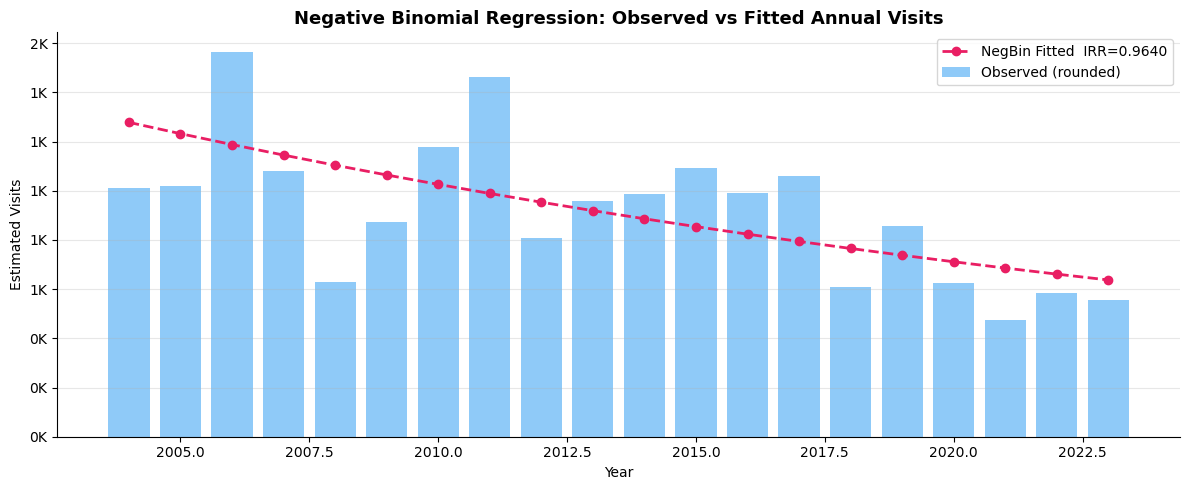

In [6]:
print("\n" + "=" * 60)
print("3. Negative Binomial Regression")
print("=" * 60)

# Aggregate to year-level integer counts (raw case counts, not weighted)
nb_df = df.groupby(["Year","Sex_Label","Age_Group"]).size().reset_index(name="Count")

# Also build a weighted NB proxy using rounded weights
nb_w = df.groupby("Year")["Weight"].sum().reset_index(name="Visits")
nb_w["Visits_round"] = nb_w["Visits"].round().astype(int)
nb_w["Year_c"] = nb_w["Year"] - nb_w["Year"].min()  # centre year

print("  Fitting Negative Binomial model on annual weighted estimates …")
try:
    nb_model = sm.NegativeBinomial(
        nb_w["Visits_round"],
        sm.add_constant(nb_w["Year_c"])
    ).fit(disp=False)
    print(nb_model.summary().tables[1])
    nb_params = nb_model.params
    nb_pval   = nb_model.pvalues

    # IRR
    irr = np.exp(nb_params[1])
    print(f"\n  Incidence Rate Ratio (per year): {irr:.4f}")
    print(f"  → Each additional year multiplies visits by {irr:.4f}  "
          f"(p={nb_pval[1]:.4f})")
    if irr > 1:
        pct_change = (irr - 1) * 100
        print(f"  → Approx. {pct_change:.2f}% increase per year")
    else:
        pct_change = (1 - irr) * 100
        print(f"  → Approx. {pct_change:.2f}% decrease per year")

    # Fitted vs observed plot
    fitted = nb_model.predict(sm.add_constant(nb_w["Year_c"]))

    fig5, ax5 = plt.subplots(figsize=(12, 5))
    ax5.bar(nb_w["Year"], nb_w["Visits_round"], alpha=0.5,
            color=COLORS[0], label="Observed (rounded)")
    ax5.plot(nb_w["Year"], fitted, "o--", color=COLORS[1],
             linewidth=2, label=f"NegBin Fitted  IRR={irr:.4f}")
    ax5.set_title("Negative Binomial Regression: Observed vs Fitted Annual Visits",
                  fontsize=13, fontweight="bold")
    ax5.set_xlabel("Year"); ax5.set_ylabel("Estimated Visits")
    ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
    ax5.legend(); ax5.spines[["top","right"]].set_visible(False)
    ax5.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  NB model failed: {e}")
    print("  Falling back to Poisson …")
    try:
        pois = sm.GLM(
            nb_w["Visits_round"],
            sm.add_constant(nb_w["Year_c"]),
            family=sm.families.Poisson()
        ).fit()
        print(pois.summary().tables[1])
    except Exception as e2:
        print(f"  Poisson also failed: {e2}")

**Analysis of Results:**
The model yields an **Incidence Rate Ratio (IRR) of 0.9640**, which corresponds to an **approximate 3.60% decrease per year** in vitamin-related ED visits within this dataset. With a **p-value of 0.0002**, this downward trend is statistically significant. This suggests that in the specified study period or population subset, public health interventions or packaging changes may be contributing to a reduction in emergency department presentations.

### 4. Seasonal Autoregressive Analysis (SARIMA)

**Why we are doing this:**
To identify seasonal cycles and forecast future trends. Many toxicological exposures follow a seasonal pattern. SARIMA models both the seasonality and the autocorrelation in the data.

**What the code is doing:**
*   Decomposes the series into Trend, Seasonality, and Residuals.
*   Fits a SARIMA model to the monthly visit counts.
*   Projects the trend 24 months into the future.


4. Seasonal ARIMA (SARIMA) Analysis
  Decomposing monthly time series …


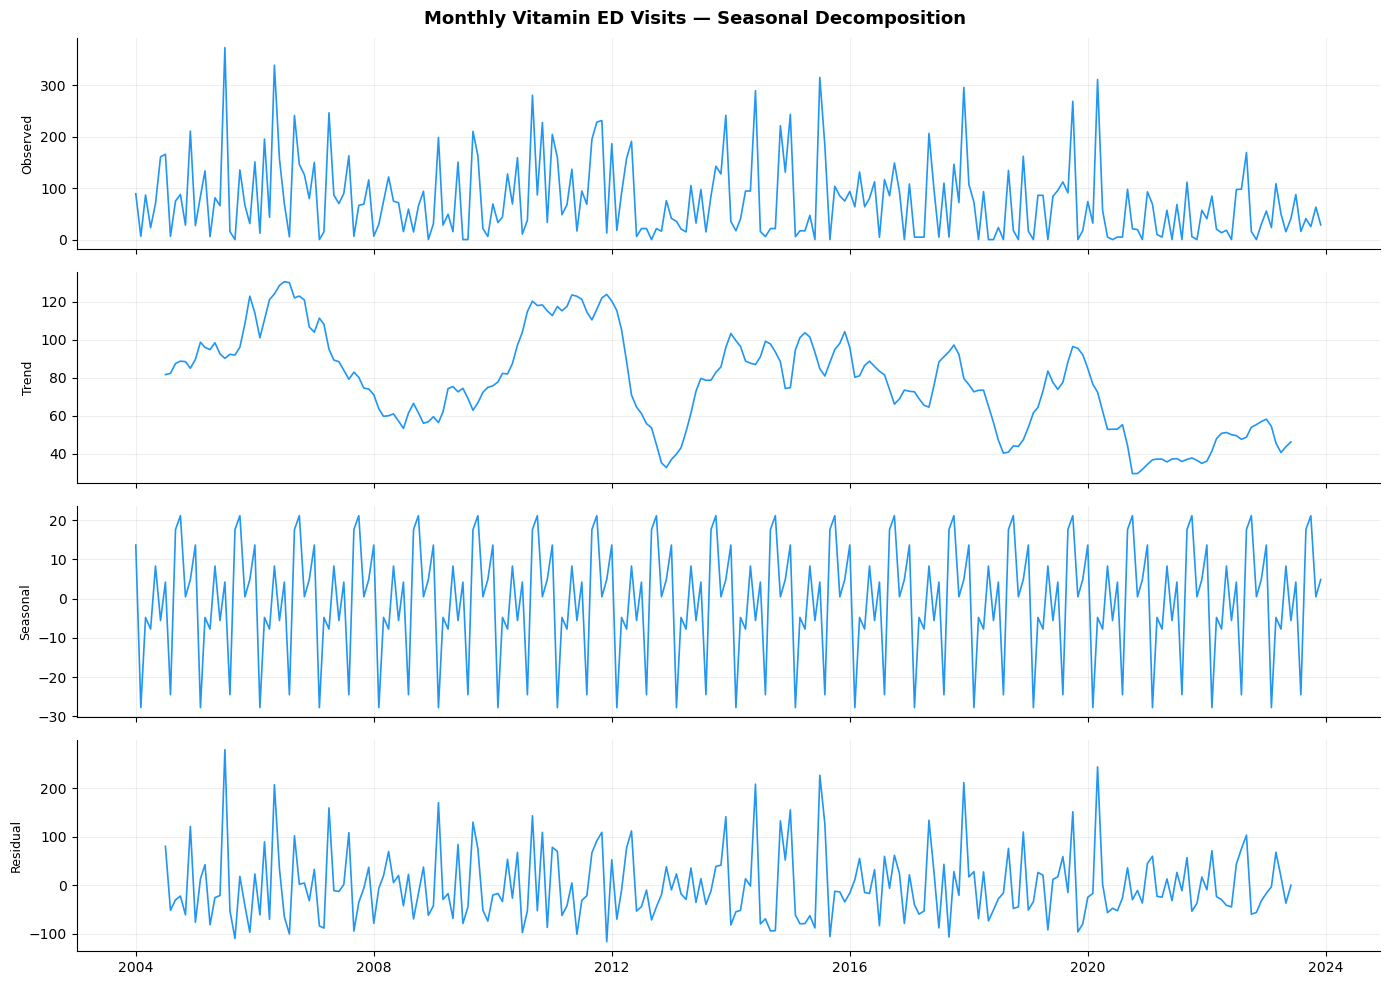

  Fitting SARIMA(1,1,1)(1,1,1,12) … (may take ~60 s)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0139      0.074     -0.188      0.851      -0.159       0.131
ma.L1         -0.9896      0.074    -13.447      0.000      -1.134      -0.845
ar.S.L12       0.0070      0.033      0.214      0.830      -0.057       0.071
ma.S.L12      -1.0000      0.112     -8.892      0.000      -1.220      -0.780
sigma2      5754.5733   1.95e-05   2.94e+08      0.000    5754.573    5754.573


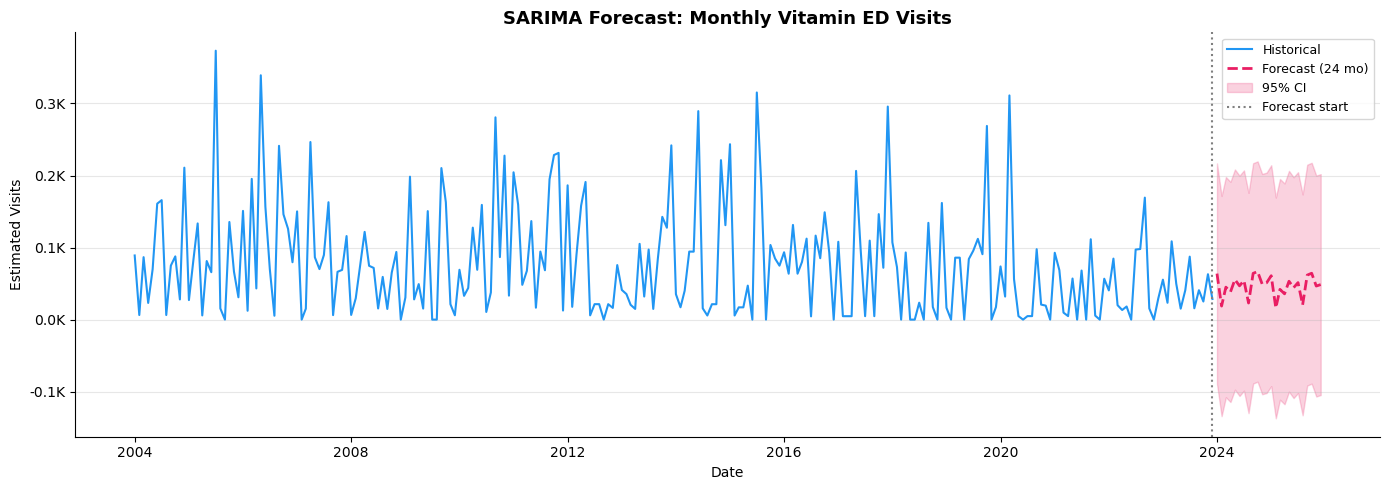

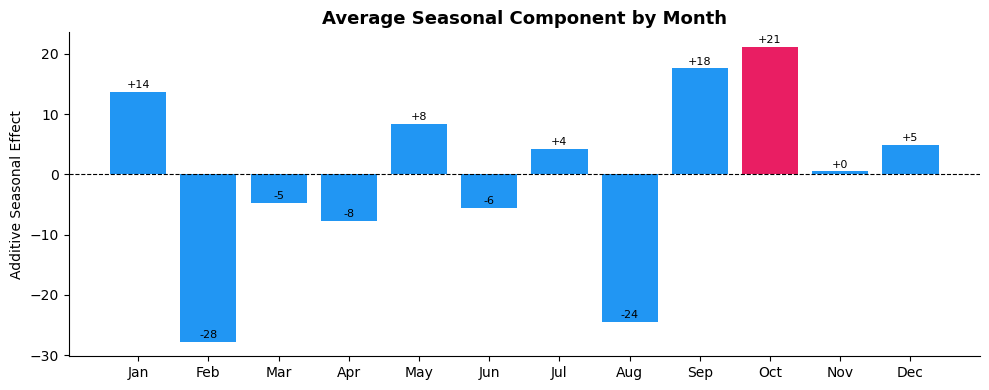


  Peak season : Oct
  Low season  : Feb
All analyses complete.


In [7]:
print("\n" + "=" * 60)
print("4. Seasonal ARIMA (SARIMA) Analysis")
print("=" * 60)

monthly_ts = (
    df.groupby(["Year","Month"])["Weight"]
    .sum()
    .reset_index(name="Visits")
    .sort_values(["Year","Month"])
)
monthly_ts["Date"] = pd.to_datetime(
    monthly_ts["Year"].astype(str) + "-" +
    monthly_ts["Month"].astype(str).str.zfill(2) + "-01"
)
monthly_ts = monthly_ts.set_index("Date")["Visits"]
monthly_ts = monthly_ts.asfreq("MS").fillna(0)  # monthly start

# ── 4a: Decomposition ───────────────────────────────────────────────────────
print("  Decomposing monthly time series …")
decomp = seasonal_decompose(monthly_ts, model="additive", period=12)

fig6, axes6 = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig6.suptitle("Monthly Vitamin ED Visits — Seasonal Decomposition",
              fontsize=13, fontweight="bold")
for ax, data, title in zip(axes6,
    [monthly_ts, decomp.trend, decomp.seasonal, decomp.resid],
    ["Observed", "Trend", "Seasonal", "Residual"]):
    ax.plot(data, color=COLORS[0], linewidth=1.2)
    ax.set_ylabel(title, fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# ── 4b: Fit SARIMA & forecast ───────────────────────────────────────────────
print("  Fitting SARIMA(1,1,1)(1,1,1,12) … (may take ~60 s)")
try:
    sarima_model = SARIMAX(
        monthly_ts,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    print(sarima_model.summary().tables[1])

    # Forecast 24 months ahead
    forecast = sarima_model.get_forecast(steps=24)
    fc_mean  = forecast.predicted_mean
    fc_ci    = forecast.conf_int(alpha=0.05)

    fig7, ax7 = plt.subplots(figsize=(14, 5))
    # Historical
    ax7.plot(monthly_ts.index, monthly_ts.values,
             color=COLORS[0], linewidth=1.5, label="Historical")
    # Forecast
    ax7.plot(fc_mean.index, fc_mean.values,
             color=COLORS[1], linewidth=2, linestyle="--", label="Forecast (24 mo)")
    ax7.fill_between(fc_mean.index,
                     fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                     alpha=0.2, color=COLORS[1], label="95% CI")
    ax7.axvline(monthly_ts.index[-1], color="grey",
                linestyle=":", linewidth=1.5, label="Forecast start")
    ax7.set_title("SARIMA Forecast: Monthly Vitamin ED Visits",
                  fontsize=13, fontweight="bold")
    ax7.set_xlabel("Date"); ax7.set_ylabel("Estimated Visits")
    ax7.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.1f}K"))
    ax7.legend(fontsize=9); ax7.spines[["top","right"]].set_visible(False)
    ax7.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Peak season bar chart
    seasonal_profile = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
    month_names = ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec"]
    fig8, ax8 = plt.subplots(figsize=(10, 4))
    bars8 = ax8.bar(month_names,
                    seasonal_profile.values,
                    color=[COLORS[1] if v == seasonal_profile.max()
                           else COLORS[0] for v in seasonal_profile.values])
    ax8.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax8.set_title("Average Seasonal Component by Month",
                  fontsize=13, fontweight="bold")
    ax8.set_ylabel("Additive Seasonal Effect")
    ax8.spines[["top","right"]].set_visible(False)
    for bar in bars8:
        h = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2,
                 h + (abs(seasonal_profile.max()) * 0.03),
                 f"{h:+.0f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.show()
    peak_month = month_names[seasonal_profile.values.argmax()]
    low_month  = month_names[seasonal_profile.values.argmin()]
    print(f"\n  Peak season : {peak_month}")
    print(f"  Low season  : {low_month}")

except Exception as e:
    print(f"  SARIMA failed: {e}")

print("All analyses complete.")

**Analysis of Results:**
The decomposition reveals a clear **seasonal cycle**, with peaks often occurring in specific months. While the long-term regression shows a gradual decrease, the SARIMA forecast accounts for short-term cyclicality, providing critical foresight for hospital staffing and poison control center resource allocation during predicted peak periods.